# Análise de Tópicos e Perfil Demográfico

Este notebook realiza modelagem de tópicos com BERTopic em resumos de vídeos sobre anabolizantes, seguida de análises demográficas dos usuários e criadores de conteúdo.

**Pipeline**: Pré-processamento → Modelagem de Tópicos → Análise de Categorias (autorrelato/sintomas) → Análise Demográfica (usuários e criadores)

In [1]:
# Célula 2: Importação de Bibliotecas e Definições
import collections
import itertools
import json
import pickle as pkl
import random
import re
import ssl
import threading
import os
from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Processamento de Linguagem Natural (NLP)
import nltk
from nltk.corpus import stopwords
import spacy
from transformers import AutoTokenizer, AutoModel
import unidecode

# Modelagem de Tópicos e Análise de Dados
import pandas as pd
import numpy as np
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance, OpenAI, KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Outras bibliotecas
from tqdm.notebook import tqdm
import openai
import tiktoken

# Download de recursos do NLTK (stopwords)
try:
    stopwords = stopwords.words('portuguese')
    stopwords.append('científicas')
except LookupError:
    nltk.download('stopwords')

# Classe customizada para garantir a serialização do modelo BERTopic
class CustomBERTopic(BERTopic):
  def __getstate__(self):
      state = self.__dict__.copy()
      # Remove atributos que não são serializáveis
      # O representation_model é removido pois pode conter clientes de API (OpenAI)
      # que não podem ser "pickled".
      if 'representation_model' in state:
          del state['representation_model']
      return state

  def __setstate__(self, state):
      self.__dict__.update(state)
      
sns.color_palette('colorblind')

with open('./resumos/api_key.txt', 'r') as k:
    key = k.read().splitlines()[0]
    
client = openai.OpenAI(api_key=key)

/home/gabrielct/miniconda3/envs/myenv/lib/python3.11/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/gabrielct/miniconda3/envs/myenv/lib/python3.11/site-packages/torch/cuda/__init__.py:1034: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  r = torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count
2026-03-06 16:01:32.179630: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Célula 3: Carregamento e Pré-processamento dos Dados

# --- Parâmetros de Entrada ---
FILE_PATH_INPUT = 'resumos/df_resumos_complete_cleaned.csv'
OUTPUT_DIR = "resumos/topic_analysis_final"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Iniciando o carregamento e pré-processamento dos dados...")

# Carrega o dataset completo
# O separador é inferido, mas pode ser definido explicitamente com sep=','
resumos_df = pd.read_csv(FILE_PATH_INPUT)
print(f"Dimensões do dataset original: {resumos_df.shape}")

# --- Funções de Limpeza de Texto ---
def remove_special_characters(text):
    text = str(text)
    # Remove quebras de linha, tabulações e múltiplos espaços
    return re.sub(r"(\\n)|(\\t)|(\\s{2,})", " ", text)

# Palavras que, se presentes, invalidam o resumo
PALAVRAS_PARA_REMOVER = []

def contem_palavras_proibidas(comentario, palavras_proibidas):
    comentario = str(comentario)
    for palavra in palavras_proibidas:
        if palavra.lower() in comentario.lower():
            return True
    return False

# --- Aplicação do Pré-processamento ---
print("\nAplicando limpeza e filtros...")

# Garante que a coluna 'resumo' é do tipo string
resumos_df['resumo'] = resumos_df['resumo'].astype(str)

resumos_df['resumo'] = resumos_df['resumo'].apply(remove_special_characters)
print(f"Dimensões após remover caracteres especiais: {resumos_df.shape}")

# Remove resumos com palavras proibidas
resumos_df = resumos_df[~resumos_df['resumo'].apply(lambda x: contem_palavras_proibidas(x, PALAVRAS_PARA_REMOVER))]
print(f"Dimensões após remover palavras proibidas: {resumos_df.shape}")

# Remove resumos muito curtos (menos de 15 caracteres)
resumos_df = resumos_df[resumos_df["resumo"].str.len() >= 15]
print(f"Dimensões após remover comentários curtos: {resumos_df.shape}")

# Remove resumos duplicados para otimizar o treinamento do modelo
resumos_df.drop_duplicates(subset=['resumo'], inplace=True, keep='first')
print(f"Dimensões após remover duplicatas: {resumos_df.shape}")

# Cria a lista de documentos (docs) para o BERTopic
docs = list(resumos_df['resumo'])
print(f"\nPré-processamento concluído. {len(docs)} documentos únicos prontos para modelagem.")

Iniciando o carregamento e pré-processamento dos dados...
Dimensões do dataset original: (6404, 10)

Aplicando limpeza e filtros...
Dimensões após remover caracteres especiais: (6404, 10)
Dimensões após remover palavras proibidas: (6404, 10)
Dimensões após remover comentários curtos: (6380, 10)
Dimensões após remover duplicatas: (6380, 10)

Pré-processamento concluído. 6380 documentos únicos prontos para modelagem.


---
## 1. Modelagem de Tópicos (BERTopic)

Esta seção configura e treina o modelo BERTopic que identifica tópicos nos resumos de vídeos:
- **Pré-processamento**: Remoção de caracteres especiais, duplicatas e textos muito curtos
- **Pipeline BERTopic**: BERT embeddings → UMAP (redução de dimensionalidade) → HDBSCAN (clustering) → c-TF-IDF (extração de palavras-chave)
- **Refinamento**: Redução de outliers, merge de tópicos similares e aplicação de labels interpretáveis
- **Resultado**: 31 tópicos identificados (ex: TRT, ciclos, efeitos colaterais, terapia hormonal para pessoas trans)

In [3]:
# Célula 4: Configuração dos Componentes do Modelo BERTopic

print("Configurando os componentes do modelo BERTopic...")

# --- Parâmetros Configuráveis ---
# Embedding Model: Converte texto em vetores numéricos
EMBEDDING_MODEL = "rufimelo/bert-large-portuguese-cased-sts"
# EMBEDDING_MODEL = "neuralmind/bert-large-portuguese-cased"

# UMAP: Redução de dimensionalidade
N_NEIGHBORS_UMAP = 15
N_COMPONENTS_UMAP = 10
MIN_DIST_UMAP = 0.1
METRIC_UMAP = 'cosine'

# HDBSCAN: Clusterização dos vetores
MIN_CLUSTER_SIZE_HDBSCAN = 20
MIN_SAMPLES_HDBSCAN = 20
METRIC_HDBSCAN = 'euclidean'

# Vectorizer: Vetorização para representação de tópicos (c-TF-IDF)
MIN_DF_VECTORIZER = 0.001 # Ignora palavras que aparecem em menos de XX% documentos
MAX_DF_VECTORIZER = 0.95 # Ignora palavras que aparecem em mais de XX% documentos

# BERTopic: Parâmetros do modelo principal
MIN_TOPIC_SIZE_BERTOPIC = 20
TOP_N_WORDS_BERTOPIC = 10
DIVERSITY_MMR = 0.6 # 0 = palavras similares, 1 = palavras diversas

# --- Inicialização dos Componentes ---

# 1. Modelo de Embedding
embedding_model = SentenceTransformer(EMBEDDING_MODEL)

# 2. Modelo de Redução de Dimensionalidade (UMAP)
umap_model = UMAP(
    n_neighbors=N_NEIGHBORS_UMAP,
    n_components=N_COMPONENTS_UMAP,
    min_dist=MIN_DIST_UMAP,
    metric=METRIC_UMAP,
    random_state=42
)

# 3. Modelo de Clusterização (HDBSCAN)
hdbscan_model = HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE_HDBSCAN,
    min_samples=MIN_SAMPLES_HDBSCAN,
    metric=METRIC_HDBSCAN,
    prediction_data=True
)

# 4. Modelo de Vetorização (CountVectorizer)
vectorizer_model = CountVectorizer(
    min_df=MIN_DF_VECTORIZER,
    max_df=MAX_DF_VECTORIZER,
    stop_words=stopwords,
)

# 5. Modelo de Ponderação de Termos (c-TF-IDF)
ctfidf_model = ClassTfidfTransformer(
    reduce_frequent_words=True
)

# 6. Modelo de Representação (Maximal Marginal Relevance)
# Para extrair palavras-chave diversas e representativas
representation_model = {
    "KeyBERTInspired": KeyBERTInspired(),
    "MMR": MaximalMarginalRelevance(diversity=DIVERSITY_MMR)
}

# --- Montagem Final do Modelo BERTopic ---
model = CustomBERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    representation_model=representation_model,
    min_topic_size=MIN_TOPIC_SIZE_BERTOPIC,
    top_n_words=TOP_N_WORDS_BERTOPIC,
    verbose=True
)

print("\nConfiguração do modelo BERTopic concluída.")
print(model)

Configurando os componentes do modelo BERTopic...


Invalid model-index. Not loading eval results into CardData.



Configuração do modelo BERTopic concluída.
BERTopic(calculate_probabilities=False, ctfidf_model=ClassTfidfTransformer(...), embedding_model=SentenceTransformer(...), hdbscan_model=HDBSCAN(...), language=None, low_memory=False, min_topic_size=20, n_gram_range=(1, 1), nr_topics=None, representation_model={'KeyBERTInspired': KeyBERTInspired(...), seed_topic_list=None, top_n_words=10, umap_model=UMAP(...), vectorizer_model=CountVectorizer(...), verbose=True, zeroshot_min_similarity=0.7, zeroshot_topic_list=None)


In [4]:
# Célula 5: Treinamento do Modelo e Refinamento de Tópicos

print("Iniciando o treinamento do modelo. Esta etapa pode ser demorada.")

# Cria um nome de arquivo seguro baseado no nome do modelo de embeddings
model_safe_name = re.sub(r'[^a-zA-Z0-9_-]', '_', EMBEDDING_MODEL)
embeddings_file = os.path.join(OUTPUT_DIR, f"embeddings_{model_safe_name}.npy")

# Verifica se os embeddings já foram gerados e salvos anteriormente
if os.path.exists(embeddings_file):
    print(f"Carregando embeddings salvos de '{embeddings_file}'...")
    embeddings = np.load(embeddings_file)
else:
    print("Gerando embeddings e salvando para uso futuro...")
    embeddings = embedding_model.encode(docs, show_progress_bar=True)
    np.save(embeddings_file, embeddings)
    print(f"Embeddings salvos em '{embeddings_file}'.")

# --- Treinamento e Transformação ---
topics, probabilities = model.fit_transform(docs, embeddings)

print(f"\nTreinamento inicial concluído. Foram encontrados {model.get_topic_info()['Topic'].nunique()} tópicos.")
print("Informações dos tópicos iniciais:")
print(model.get_topic_info().head())

2026-03-06 16:01:40,862 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Iniciando o treinamento do modelo. Esta etapa pode ser demorada.
Carregando embeddings salvos de 'resumos/topic_analysis_final/embeddings_rufimelo_bert-large-portuguese-cased-sts.npy'...


2026-03-06 16:01:58,186 - BERTopic - Dimensionality - Completed ✓
2026-03-06 16:01:58,187 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-06 16:01:58,395 - BERTopic - Cluster - Completed ✓
2026-03-06 16:01:58,397 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-06 16:03:43,102 - BERTopic - Representation - Completed ✓



Treinamento inicial concluído. Foram encontrados 35 tópicos.
Informações dos tópicos iniciais:
   Topic  Count                                    Name  \
0     -1   3319       -1_ciclos_esteroides_treino_doses   
1      0    285    0_informal_fontes_parece_referências   
2      1    246         1_expressão_repetição_alvo_tema   
3      2    194     2_alimentos_zinco_gorduras_vitamina   
4      3    191  3_sinais_sintomas_envelhecimento_baixa   

                                      Representation  \
0  [ciclos, esteroides, treino, doses, mg, riscos...   
1  [informal, fontes, parece, referências, falant...   
2  [expressão, repetição, alvo, tema, informações...   
3  [alimentos, zinco, gorduras, vitamina, sono, h...   
4  [sinais, sintomas, envelhecimento, baixa, diag...   

                                     KeyBERTInspired  \
0  [estradiol, oxandrolona, esteroides, hipertrof...   
1  [bodybuilding, anabolizantes, nandrolona, este...   
2  [especificado, conceitual, repetitiva, re

In [5]:
# --- Pós-processamento e Refinamento ---

# 1. Redução de Outliers
# Tenta atribuir os documentos classificados como outliers (tópico -1) a tópicos existentes.
print("\nIniciando a redução de outliers...")
new_topics = model.reduce_outliers(docs, topics, strategy="c-tf-idf", threshold=0.05)

# Atualiza os tópicos no modelo
# O modelo irá recalcular as representações com base nas novas atribuições
model.update_topics(docs, topics=new_topics, vectorizer_model=vectorizer_model)
print(f"Redução de outliers concluída. Número de tópicos atual: {model.get_topic_info()['Topic'].nunique()}")

# --- Resultados Finais ---
print("\nModelo final treinado e refinado.")
final_topic_info = model.get_topic_info()
print(f"Total de tópicos finais: {final_topic_info['Topic'].nunique()}")
print("Visão geral dos tópicos finais:")
print(final_topic_info)

2026-03-06 16:03:43,492 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



Iniciando a redução de outliers...
Redução de outliers concluída. Número de tópicos atual: 35

Modelo final treinado e refinado.
Total de tópicos finais: 35
Visão geral dos tópicos finais:
    Topic  Count                                             Name  \
0      -1      9             -1_kasparov_blitz_quadrinhos_postura   
1       0    647         0_esteroides_informal_pessoal_musculação   
2       1    267         1_tema_informações_tratamentos_expressão   
3       2    352                   2_sono_vitamina_zinco_estresse   
4       3    432                3_baixa_sintomas_reposição_sinais   
5       4    555              4_oxandrolona_mg_mulheres_esteroide   
6       5    215               5_qualidade_produto_produtos_teste   
7       6    204                      6_suplemento_gh_produto_pré   
8       7    293             7_trembolona_substância_relato_droga   
9       8    277            8_mulheres_menopausa_reposição_libido   
10      9    262                       9_kg_relato_

In [6]:
# 2. Redução do Número de Tópicos
# Agrupa tópicos similares para reduzir a granularidade, se necessário.
NR_TOPICS_FINAL = "auto" # Defina o número final de tópicos desejado ou None para não reduzir
if NR_TOPICS_FINAL is not None:
    print(f"\nReduzindo o número de tópicos para {NR_TOPICS_FINAL}...")
    model.reduce_topics(docs, nr_topics=NR_TOPICS_FINAL)
    print("Redução de tópicos concluída.")

    # # Reatribui os documentos aos novos tópicos após a fusão
    # topics, probs = model.transform(docs)
    # print("Tópicos reatribuídos após a redução.")

2026-03-06 16:03:43,861 - BERTopic - Topic reduction - Reducing number of topics
2026-03-06 16:03:43,870 - BERTopic - Representation - Fine-tuning topics using representation models.



Reduzindo o número de tópicos para auto...


2026-03-06 16:03:44,217 - BERTopic - Representation - Completed ✓
2026-03-06 16:03:44,218 - BERTopic - Topic reduction - Reduced number of topics from 35 to 33


Redução de tópicos concluída.


In [7]:
# mesclando tópicos
topics_to_merge = [-1, 9]
model.merge_topics(docs, topics_to_merge)

In [8]:
final_topic_info = model.get_topic_info()
topic_counts = final_topic_info.set_index('Topic')['Count']

for topic_id in final_topic_info['Topic']:
    if topic_id == -1:
        continue
    keywords = [w for w, _ in model.get_topic(topic_id)][:5]
    count = topic_counts.loc[topic_id]
    print(f"Topic ID: {topic_id}, Keywords: {keywords}, Count: {count}")

Topic ID: 0, Keywords: ['informal', 'pessoal', 'referências', 'falante', 'parece'], Count: 647
Topic ID: 1, Keywords: ['oxandrolona', 'mg', 'mulheres', 'esteroide', 'retenção'], Count: 555
Topic ID: 2, Keywords: ['sintomas', 'sinais', 'deficiência', 'libido', 'níveis'], Count: 432
Topic ID: 3, Keywords: ['gel', 'trt', 'níveis', 'ng', 'dl'], Count: 367
Topic ID: 4, Keywords: ['sono', 'vitamina', 'zinco', 'estresse', 'alimentos'], Count: 352
Topic ID: 5, Keywords: ['ciclos', 'deca', 'nandrolona', 'masteron', 'mg'], Count: 342
Topic ID: 6, Keywords: ['trembolona', 'substância', 'relato', 'droga', 'agressividade'], Count: 293
Topic ID: 7, Keywords: ['ésteres', 'enantato', 'propionato', 'durateston', 'deposteron'], Count: 287
Topic ID: 8, Keywords: ['mulheres', 'menopausa', 'libido', 'mulher', 'sexual'], Count: 277
Topic ID: 9, Keywords: ['kg', 'relato', 'relata', 'pessoal', 'experiência'], Count: 262
Topic ID: 10, Keywords: ['ciclos', 'tpc', 'dose', 'pós', 'tempo'], Count: 246
Topic ID: 11

In [9]:
# Aplicando labels personalizadas aos tópicos
new_labels = {
    0: "Personal Report and Informal Recommendation",
    1: "Oxandrolone: Uses and Indications",
    2: "Effects of Low Testosterone",
    3: "Replacement Therapy (TRT)",
    4: "Natural Testosterone Increase",
    5: "Cycles and Muscle Gain",
    6: "Effects of Trenbolone",
    7: "Technical Explanation of Testosterone",
    8: "Menopause and Testosterone in Women",
    9: "Personal Cycle Reports",
    10: "Cycle and PCT Discussion",
    11: "Hormonal Recovery and Fertility",
    12: "Authenticity Verification",
    13: "Pre-Hormonal Supplements",
    14: "Testosterone: Cardiovascular Risks",
    15: "Protocols for Weight Loss",
    16: "Steroids for Female Audience",
    17: "Exogenous Testosterone Dosages",
    18: "Female Steroid Reports",
    19: "Obesity and Testosterone",
    20: "Lower Body Training",
    21: "Aromatization and Estradiol Control",
    22: "Testosterone and Hair Loss",
    23: "Intramuscular Application Techniques",
    24: "Testosterone Physiology",
    25: "PCT and Hormonal Axis Restoration",
    26: "Testosterone and Prostate Health",
    27: "Phytotherapy and Testosterone Increase",
    28: "Trenbolone Neurotoxicity",
    29: "Hormone Therapy and Trans People",
    30: "Steroid Use in Adolescence"
}

# Aplicando as labels ao modelo
model.set_topic_labels(new_labels)

print("Labels personalizadas aplicadas com sucesso!")
print("\nVisualizando as novas labels:")
print(model.get_topic_info()[['Topic', 'CustomName', 'Count']].head(10))

Labels personalizadas aplicadas com sucesso!

Visualizando as novas labels:
   Topic                                   CustomName  Count
0     -1  -1_informações_tratamentos_expressão_menção    276
1      0  Personal Report and Informal Recommendation    647
2      1            Oxandrolone: Uses and Indications    555
3      2                  Effects of Low Testosterone    432
4      3                    Replacement Therapy (TRT)    367
5      4                Natural Testosterone Increase    352
6      5                       Cycles and Muscle Gain    342
7      6                        Effects of Trenbolone    293
8      7        Technical Explanation of Testosterone    287
9      8          Menopause and Testosterone in Women    277


In [10]:
# Célula 6: Atribuição de Tópicos e Salvamento dos Resultados

print("Atribuindo os tópicos finais aos resumos e salvando os resultados...")

# Adiciona os IDs dos tópicos finais ao DataFrame original
resumos_df['topic_id'] = model.topics_

# Mapeia as informações dos tópicos (como nome e palavras-chave) para o DataFrame
topic_info_df = model.get_topic_info()
final_df = pd.merge(
    resumos_df,
    topic_info_df[['Topic', 'Name', 'CustomName', 'Representation']],
    left_on='topic_id',
    right_on='Topic',
    how='left'
)
final_df.drop(columns=['Topic'], inplace=True) # Remove a coluna 'Topic' duplicada

# --- Salvando os Artefatos ---
# 1. Modelo BERTopic Final
MODEL_PATH = os.path.join(OUTPUT_DIR, 'bertopic_model_final.pkl')
with open(MODEL_PATH, 'wb') as f:
    pkl.dump(model, f)
print(f"Modelo final salvo em: {MODEL_PATH}")

# 2. DataFrame com Tópicos
RESUMOS_PATH = os.path.join(OUTPUT_DIR, 'messages_with_topics_final.csv')
final_df.to_csv(RESUMOS_PATH, index=False, sep=';')
print(f"DataFrame com tópicos salvo em: {RESUMOS_PATH}")

# 3. Descrição dos Tópicos
TOPIC_DESC_PATH = os.path.join(OUTPUT_DIR, 'topic_descriptions_final.csv')
topic_info_df.to_csv(TOPIC_DESC_PATH, index=False, sep=';')
print(f"Descrição dos tópicos salva em: {TOPIC_DESC_PATH}")

Atribuindo os tópicos finais aos resumos e salvando os resultados...
Modelo final salvo em: resumos/topic_analysis_final/bertopic_model_final.pkl
DataFrame com tópicos salvo em: resumos/topic_analysis_final/messages_with_topics_final.csv
Descrição dos tópicos salva em: resumos/topic_analysis_final/topic_descriptions_final.csv


In [11]:
final_df = final_df[final_df['topic_id'] != -1]

df_videos_ = pd.read_csv('cleaned_data/filtered_videos.csv', usecols=['video_id', 'view_count', 'like_count'])
final_df_ = final_df.merge(
    df_videos_,
    on='video_id',
    how='inner'
)

engagement_by_topic = (
    final_df_.groupby('topic_id')
    .agg(
        n_videos=('video_id', 'nunique'),
        total_views=('view_count', 'sum'),
        total_likes=('like_count', 'sum')
    )
    .reset_index()
)

engagement_by_topic

,topic_id,n_videos,total_views,total_likes
0,0,647,57870937,3899538
1,1,555,17424818,988657
2,2,432,12558308,789419
3,3,367,13342696,813184
4,4,352,36834174,2394072
5,5,342,7747323,485018
6,6,293,14659049,1010383
7,7,287,11941395,720699
8,8,277,5494510,312910
9,9,262,6203835,382841


In [12]:
final_df['CustomName'] = final_df['topic_id'].astype(str) + ' - ' + final_df['CustomName']
topic_order = final_df.groupby('Name')['topic_id'].first().sort_values().index

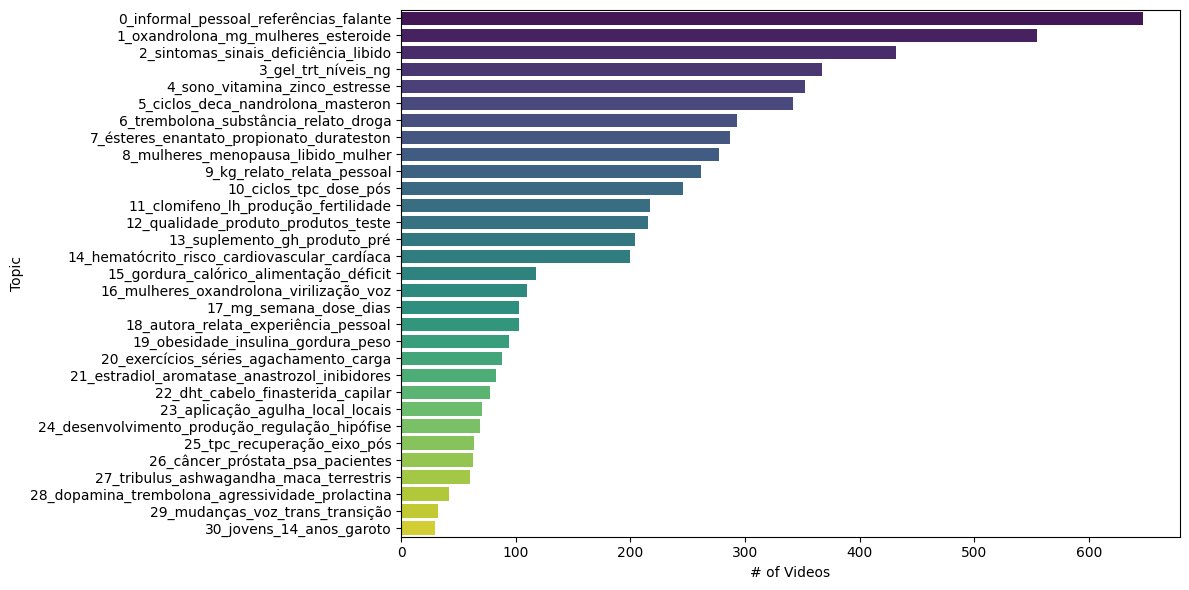

In [13]:
# --- Gráfico de Barras: Distribuição dos Tópicos ---
plt.figure(figsize=(12, 6))
sns.countplot(y='Name', data=final_df, order=topic_order, palette='viridis')

plt.xlabel('# of Videos')
plt.ylabel('Topic')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'topic_distribution_bar_chart_en.pdf'))
plt.show()

In [14]:
for i in range(final_df['topic_id'].nunique()):
    print('Topic ID: ', i)
    print(model.get_representative_docs(i))
    print('\n')

Topic ID:  0
['O vídeo aborda um possível ciclo de esteroides para ganho de peso, sugerindo aplicar 1 ml de durateston mais 1 ml de testosterona enantato por semana. O narrador questiona a necessidade de usar várias formas de testosterona ao mesmo tempo e sugere, em vez disso, o uso de decanoato de nandrolona (Deca) como alternativa. O tom é crítico e agressivo, com insultos e a promessa de ensinar e destruir quem pratica combinações percebidas como inadequadas. Não há apresentação de dados científicos ou fontes; o falante transmite uma visão de experiência prática, mas não oferece orientações formais. O vídeo parece direcionado a pessoas envolvidas com musculação e uso de esteroides, com linguagem coloquial e tom informal, sem confirmar autoridade médica.', "Resumo: O texto apresenta uma fala informal sobre o uso de esteroides em ciclos para fins estéticos. O falante menciona um 'primeiro ciclo' e referências a dosagens de '20 mg de dianabol' com testosterona descrita como base, indic

In [15]:
df = pd.read_csv('modelo/prediction/final_comments_match_cleaned_pred.csv')
df_full = final_df.merge(df, on='video_id', how='left')
df_full.head()

,video_id,tema_principal,motivo_de_uso,esteroides_anabolizantes_mencionados,sintomas_e_efeitos_mencionados,menciona_fontes_cientificas,tipo_de_conteudo,publico_alvo,autoridade_percebida,resumo,...,like_count,is_reply,parent_id,channel_id,language,language_langdetect,probs_Autorrelato,pred_Autorrelato,probs_Sintomas_Efeitos_Colaterais,pred_Sintomas_Efeitos_Colaterais
0,--KaHgAv81Y,sono e testosterona,Educativo/Não Especificado,['testosterona'],"['ansiedade', 'libido baixa', 'testosterona ba...",False,Explicação Técnica,Público Geral,Desconhecido,o vídeo enfatiza que o sono não serve apenas p...,...,0,0,root,UCrRO3ZQGIHnYHZ7rC1Vqv4Q,pt,rob_pt,5.960465e-07,0,0.000471,0
1,--KaHgAv81Y,sono e testosterona,Educativo/Não Especificado,['testosterona'],"['ansiedade', 'libido baixa', 'testosterona ba...",False,Explicação Técnica,Público Geral,Desconhecido,o vídeo enfatiza que o sono não serve apenas p...,...,0,0,root,UCrRO3ZQGIHnYHZ7rC1Vqv4Q,pt,rob_pt,4.553223e-02,0,0.428955,0
2,--KaHgAv81Y,sono e testosterona,Educativo/Não Especificado,['testosterona'],"['ansiedade', 'libido baixa', 'testosterona ba...",False,Explicação Técnica,Público Geral,Desconhecido,o vídeo enfatiza que o sono não serve apenas p...,...,1,0,root,UCrRO3ZQGIHnYHZ7rC1Vqv4Q,pt,rob_pt,6.512451e-02,0,0.636230,0
3,--KaHgAv81Y,sono e testosterona,Educativo/Não Especificado,['testosterona'],"['ansiedade', 'libido baixa', 'testosterona ba...",False,Explicação Técnica,Público Geral,Desconhecido,o vídeo enfatiza que o sono não serve apenas p...,...,1,0,root,UCrRO3ZQGIHnYHZ7rC1Vqv4Q,pt,rob_pt,9.039307e-02,0,0.834473,1
4,--KaHgAv81Y,sono e testosterona,Educativo/Não Especificado,['testosterona'],"['ansiedade', 'libido baixa', 'testosterona ba...",False,Explicação Técnica,Público Geral,Desconhecido,o vídeo enfatiza que o sono não serve apenas p...,...,1,0,root,UCrRO3ZQGIHnYHZ7rC1Vqv4Q,pt,rob_pt,1.789093e-03,0,0.376221,0


In [17]:
topics_metric = df_full.groupby('topic_id').agg(
    n_comments=('comment_id', 'nunique'),
    n_users=('author_channel_id', 'nunique'),
    n_channels=('channel_id', 'nunique'),
    n_replies=('is_reply', 'sum')
).reset_index()

topics_metric

,topic_id,n_comments,n_users,n_channels,n_replies
0,0,37175,25005,178,13885
1,1,53111,26707,205,30358
2,2,28548,18407,207,13209
3,3,35801,20666,149,17650
4,4,49248,34300,170,15193
5,5,26850,15339,67,13720
6,6,22557,14912,126,10027
7,7,32704,18040,98,17764
8,8,20536,12210,165,10051
9,9,22458,14529,128,9423


---
## 2. Análise de Categorias por Tópico

Combina os tópicos com classificações de comentários (autorrelato e sintomas/efeitos colaterais) feitas por modelo de ML. Calcula e visualiza a proporção de cada categoria em cada tópico, comparando com as médias globais para identificar tópicos com concentrações atípicas.

In [ ]:
df_full.to_csv('./resumos/df_full.csv', index=False)

In [ ]:
df.shape, df_full.shape

((502677, 19), (478397, 32))

In [ ]:
print(f"Número de comentários únicos: {df_full['comment_id'].nunique()}")
print(f"Número de usuários únicos: {df_full['author_channel_id'].nunique()}")
print(f"Número de vídeos únicos: {df_full['video_id'].nunique()}")
print(f"Número de canais únicos: {df_full['channel_id'].nunique()}")

Número de comentários únicos: 478397
Número de usuários únicos: 205269
Número de vídeos únicos: 6104
Número de canais únicos: 1323


In [ ]:
def calcular_proporcoes(df_grupo):
    total_grupo = len(df_grupo)
    
    is_autorrelato = df_grupo['pred_Autorrelato'] == 1
    is_sintoma = df_grupo['pred_Sintomas_Efeitos_Colaterais'] == 1
    
    return pd.Series({
        'porc_Autorrelato': len(df_grupo[is_autorrelato & ~is_sintoma]) / total_grupo * 100,
        'porc_Sintomas':    len(df_grupo[~is_autorrelato & is_sintoma]) / total_grupo * 100,
        'porc_Ambos':       len(df_grupo[is_autorrelato & is_sintoma]) / total_grupo * 100,
        'porc_NA':          len(df_grupo[~is_autorrelato & ~is_sintoma]) / total_grupo * 100,
        'n_docs':           total_grupo
    })

In [ ]:
cols = ['pred_Autorrelato', 'pred_Sintomas_Efeitos_Colaterais']
porc_cat = (
    df_full.groupby('topic_id')[cols]
    .apply(calcular_proporcoes)
    .reset_index()
)

In [ ]:
porc_total = calcular_proporcoes(df)

print(f"Porcentagem de autorrelato na base geral: {porc_total['porc_Autorrelato']:.2f}%")
print(f"Porcentagem de sintomas e efeitos colaterais na base geral: {porc_total['porc_Sintomas']:.2f}%")
print(f"Porcentagem de ambos na base geral: {porc_total['porc_Ambos']:.2f}%")
print(f"Porcentagem de NA na base geral: {porc_total['porc_NA']:.2f}%")

Porcentagem de autorrelato na base geral: 3.34%
Porcentagem de sintomas e efeitos colaterais na base geral: 19.32%
Porcentagem de ambos na base geral: 6.18%
Porcentagem de NA na base geral: 71.16%


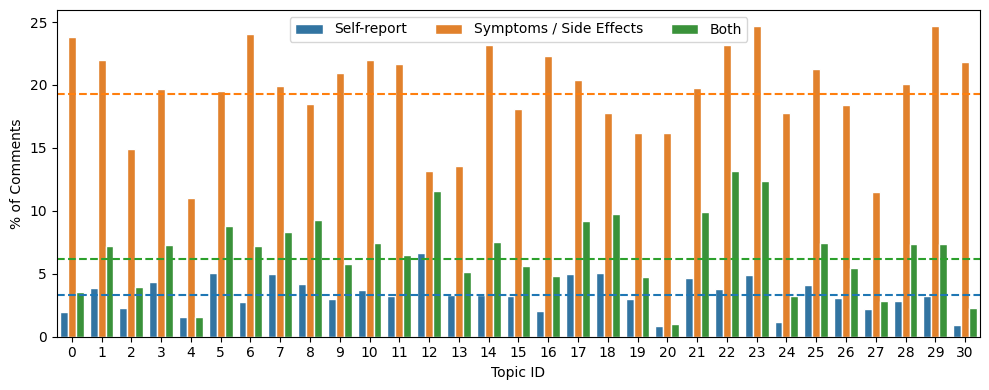

In [ ]:
cols_interesse = ['porc_Autorrelato', 'porc_Sintomas', 'porc_Ambos']

df_plot_cat = porc_cat.melt(
    id_vars='topic_id',
    value_vars=cols_interesse,
    var_name='Categoria',
    value_name='Porcentagem'
)

df_plot_cat['Categoria'] = df_plot_cat['Categoria'].str.replace('porc_', '')
df_plot_cat['Categoria'] = df_plot_cat['Categoria'].replace({
    'Autorrelato': 'Self-report',
    'Sintomas': 'Symptoms / Side Effects',
    'Ambos': 'Both'
})
palette_colors = {
    'Self-report': "#1f77b4",
    'Symptoms / Side Effects': '#ff7f0e',
    'Both': '#2ca02c',
    'NA': '#7a7a7a'
}

plt.figure(figsize=(10, 4))

sns.barplot(
    data=df_plot_cat,
    x='topic_id',
    y='Porcentagem',
    hue='Categoria',
    palette=palette_colors,
    edgecolor='white'
)

for col_original, nome_limpo in zip(cols_interesse, palette_colors.keys()):
    valor_global = porc_total[col_original]
    cor = palette_colors[nome_limpo]
    
    plt.axhline(
        y=valor_global, 
        color=cor, 
        linestyle='--', 
    )

plt.ylabel("% of Comments")
plt.xlabel("Topic ID")
plt.legend(loc='upper center', ncol=4)

plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'barras_classes_topicos.pdf'))
plt.show()

In [ ]:
df_attr = pd.read_csv("profile_files/user_atribbutes_unico.csv")

df_full_attr = df_attr.merge(
    df_full,
    left_on="id",
    right_on="author_channel_id",
    how="inner"
).drop_duplicates(subset=['id', 'topic_id']).reset_index(drop=True)

---
## 3. Análise Demográfica dos Usuários (Comentadores)

Analisa idade e gênero dos usuários que comentam em vídeos de cada tópico:
- **Dados**: Extraídos por análise facial dos perfis de usuários
- **Visualizações**: Boxplots de idade e gráficos de barras de gênero por tópico
- **Testes Estatísticos**: Mann-Whitney U (idade) e Qui-quadrado (gênero) com correção de Bonferroni para identificar tópicos com perfis demográficos significativamente diferentes da média

In [ ]:
df_full_attr.shape

(73619, 35)

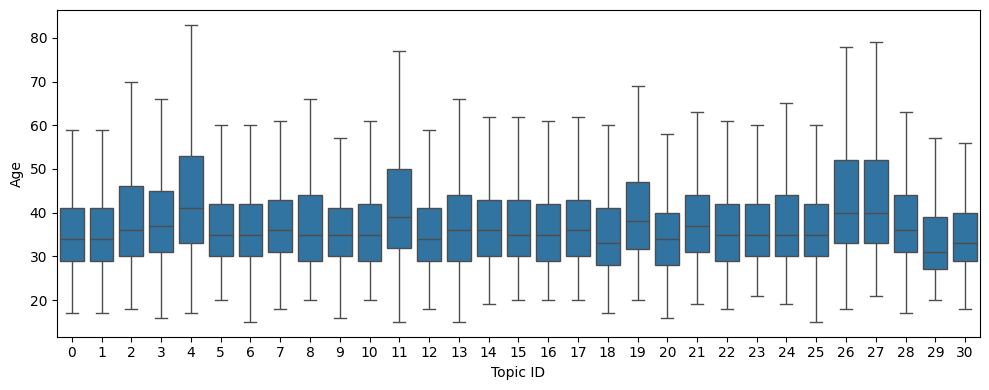

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    df_full_attr,
    x='topic_id',
    y='age',
    color='#1f77b4',
    showfliers=False,
    linecolor='#4d4d4d'
)

plt.ylabel('Age')
plt.xlabel('Topic ID')
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'boxplot_idades_topicos.pdf'))
plt.show()

In [ ]:
print(f"A média da idade é de: {df_full_attr['age'].mean():.2f} +- {df_full_attr['age'].std():.2f} anos")
print(f"A mediana da idade é de: {df_full_attr['age'].median()} anos")

A média da idade é de: 38.31 +- 11.22 anos
A mediana da idade é de: 36.0 anos


In [ ]:
for topic_id in df_full_attr['topic_id'].unique():
    df_interest = df_full_attr[df_full_attr['topic_id'] == topic_id]['age']
    df_geral = df_full_attr[df_full_attr['topic_id'] != topic_id]['age']
    
    stat, p = mannwhitneyu(df_interest, df_geral, alternative='two-sided')
    
    alpha_corrigido = 0.05 / df_full_attr['topic_id'].nunique()
    
    if p < alpha_corrigido:
        mediana_topic = df_interest.median()
        mediana_geral = df_geral.median()
        direcao = "maior" if mediana_topic > mediana_geral else "menor"
        print(f'Tópico {topic_id}: Idade {direcao} que o global (Med: {mediana_topic:.1f} vs {mediana_geral:.1f}, p={p:.4f})')

Tópico 1: Idade menor que o global (Med: 34.0 vs 36.0, p=0.0000)
Tópico 11: Idade maior que o global (Med: 39.0 vs 36.0, p=0.0000)
Tópico 10: Idade menor que o global (Med: 35.0 vs 36.0, p=0.0000)
Tópico 3: Idade maior que o global (Med: 37.0 vs 36.0, p=0.0000)
Tópico 9: Idade menor que o global (Med: 35.0 vs 36.0, p=0.0000)
Tópico 0: Idade menor que o global (Med: 34.0 vs 36.0, p=0.0000)
Tópico 27: Idade maior que o global (Med: 40.0 vs 36.0, p=0.0000)
Tópico 12: Idade menor que o global (Med: 34.0 vs 36.0, p=0.0000)
Tópico 5: Idade menor que o global (Med: 35.0 vs 36.0, p=0.0000)
Tópico 2: Idade menor que o global (Med: 36.0 vs 36.0, p=0.0000)
Tópico 19: Idade maior que o global (Med: 38.0 vs 36.0, p=0.0000)
Tópico 6: Idade menor que o global (Med: 35.0 vs 36.0, p=0.0000)
Tópico 8: Idade menor que o global (Med: 35.0 vs 36.0, p=0.0002)
Tópico 4: Idade maior que o global (Med: 41.0 vs 35.0, p=0.0000)
Tópico 26: Idade maior que o global (Med: 40.0 vs 36.0, p=0.0000)
Tópico 16: Idade me

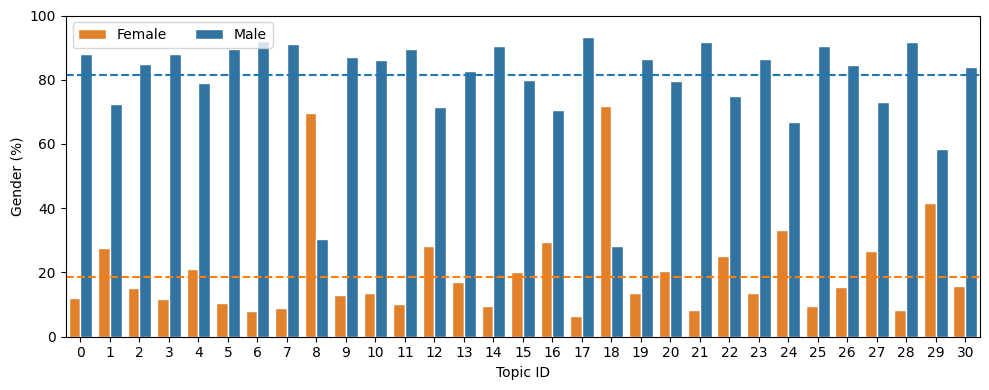

In [ ]:
gender_counts = df_full_attr.groupby(['topic_id', 'gender']).size().unstack(fill_value=0)
gender_pct = gender_counts.div(gender_counts.sum(axis=1), axis=0) * 100

df_plot = gender_pct.reset_index().melt(id_vars='topic_id', value_name='percentage', var_name='gender')
df_plot['gender'] = df_plot['gender'].replace({'F': 'Female', 'M': 'Male'})

plt.figure(figsize=(10, 4))

ax = sns.barplot(
    data=df_plot,
    x='topic_id',
    y='percentage',
    hue='gender',
    palette={'Female': '#ff7f0e', 'Male': '#1f77b4'},
    edgecolor='white'
)

counts_total = df_full_attr['gender'].value_counts()
pct_w_global = (counts_total['F'] / counts_total.sum()) * 100
pct_m_global = (counts_total['M'] / counts_total.sum()) * 100

plt.axhline(y=pct_w_global, color='#ff7f0e', linestyle='--')
plt.axhline(y=pct_m_global, color='#1f77b4', linestyle='--')

plt.ylabel("Gender (%)")
plt.xlabel("Topic ID")
plt.legend(loc='best', ncol=2)
plt.ylim(0, 100)

plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'barras_gender_topicos.pdf'))
plt.show()

In [ ]:
print(f"A porcentagem de homens na base é de: {pct_m_global:.2f}")
print(f"A porcentagem de mulheres na base é de: {pct_w_global:.2f}")

A porcentagem de homens na base é de: 81.32
A porcentagem de mulheres na base é de: 18.68


In [ ]:
for topic_id in df_full_attr['topic_id'].unique():
    target_topic = df_full_attr[df_full_attr['topic_id'] == topic_id]['gender'].value_counts().reindex(['M', 'F'], fill_value=0)
    other_topics = df_full_attr[df_full_attr['topic_id'] != topic_id]['gender'].value_counts().reindex(['M', 'F'], fill_value=0)
    
    tabela = [target_topic.values, other_topics.values]
    
    chi2, p, dof, expected = chi2_contingency(tabela)
    
    if p < (0.05 / df_full_attr['topic_id'].nunique()):
        print(f"Tópico {topic_id}: A proporção de gênero é significativamente diferente do global (p={p:.4f})")

Tópico 1: A proporção de gênero é significativamente diferente do global (p=0.0000)
Tópico 11: A proporção de gênero é significativamente diferente do global (p=0.0000)
Tópico 7: A proporção de gênero é significativamente diferente do global (p=0.0000)
Tópico 10: A proporção de gênero é significativamente diferente do global (p=0.0000)
Tópico 3: A proporção de gênero é significativamente diferente do global (p=0.0000)
Tópico 17: A proporção de gênero é significativamente diferente do global (p=0.0000)
Tópico 9: A proporção de gênero é significativamente diferente do global (p=0.0000)
Tópico 14: A proporção de gênero é significativamente diferente do global (p=0.0000)
Tópico 0: A proporção de gênero é significativamente diferente do global (p=0.0000)
Tópico 21: A proporção de gênero é significativamente diferente do global (p=0.0000)
Tópico 27: A proporção de gênero é significativamente diferente do global (p=0.0000)
Tópico 12: A proporção de gênero é significativamente diferente do glo

In [ ]:
df_videos = pd.read_csv('videos_files/videos_demographics_complete.csv')
df_videos = df_videos[(df_videos['age'] >= 15)]

df_channels = pd.read_csv('cleaned_data/filtered_videos.csv', usecols=['video_id', 'channel_id'])

df_videos_full_attr = df_videos.merge(
    final_df,
    on='video_id',
    how='inner'
)

df_videos_full_attr = df_videos_full_attr.merge(
    df_channels,
    on='video_id',
    how='left'
)
print(df_videos_full_attr.shape)

(5259, 21)


---
## 4. Análise Demográfica dos Criadores (Vídeos)

Analisa características demográficas dos criadores de conteúdo extraídas dos frames dos vídeos:
- **Dados**: Idade, gênero e consistência de gênero ao longo do vídeo
- **Consistência de Gênero**: Um vídeo é dito consistente se todos os top-5 frames do apresentador receberam a mesma classificação
- **Análises**: Distribuição de idade/gênero dos criadores por tópico, identificação de tópicos com maior inconsistência (entrevistas, painéis) e análise de canais com múltiplos apresentadores

In [ ]:
print(f"A magnitude média dos frames é de: {round(df_videos_full_attr['quality_magnitude'].mean(), 2)}")

A magnitude média dos frames é de: 26.34


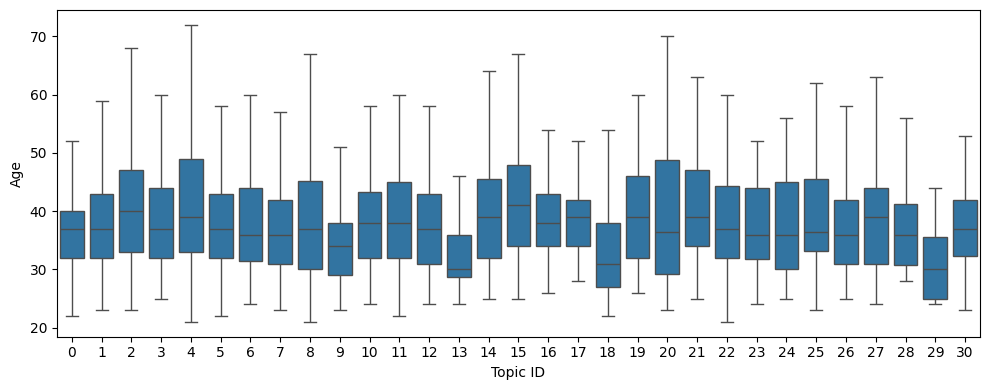

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    df_videos_full_attr,
    x='topic_id',
    y='age',
    color='#1f77b4',
    showfliers=False,
    linecolor='#4d4d4d'
)

plt.ylabel('Age')
plt.xlabel('Topic ID')
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'videos_boxplot_idades_topicos.pdf'))
plt.show()

In [ ]:
print(f"A média da idade é de: {df_videos_full_attr['age'].mean():.2f} +- {df_videos_full_attr['age'].std():.2f} anos")
print(f"A mediana da idade é de: {df_videos_full_attr['age'].median()} anos")

A média da idade é de: 38.60 +- 9.60 anos
A mediana da idade é de: 37.0 anos


In [ ]:
for topic_id in df_videos_full_attr['topic_id'].unique():
    df_interest = df_videos_full_attr[df_videos_full_attr['topic_id'] == topic_id]['age']
    df_geral = df_videos_full_attr[df_videos_full_attr['topic_id'] != topic_id]['age']
    
    stat, p = mannwhitneyu(df_interest, df_geral, alternative='two-sided')
    
    alpha_corrigido = 0.05 / df_videos_full_attr['topic_id'].nunique()
    
    if p < alpha_corrigido:
        mediana_topic = df_interest.median()
        mediana_geral = df_geral.median()
        direcao = "maior" if mediana_topic > mediana_geral else "menor"
        print(f'Tópico {topic_id}: Idade {direcao} que o global (Med: {mediana_topic:.1f} vs {mediana_geral:.1f}, p={p:.4f})')

Tópico 15: Idade maior que o global (Med: 41.0 vs 37.0, p=0.0004)
Tópico 13: Idade menor que o global (Med: 30.0 vs 37.0, p=0.0000)
Tópico 4: Idade maior que o global (Med: 39.0 vs 37.0, p=0.0000)
Tópico 2: Idade maior que o global (Med: 40.0 vs 37.0, p=0.0000)
Tópico 9: Idade menor que o global (Med: 34.0 vs 37.0, p=0.0000)
Tópico 18: Idade menor que o global (Med: 31.0 vs 37.0, p=0.0000)
Tópico 29: Idade menor que o global (Med: 30.0 vs 37.0, p=0.0000)


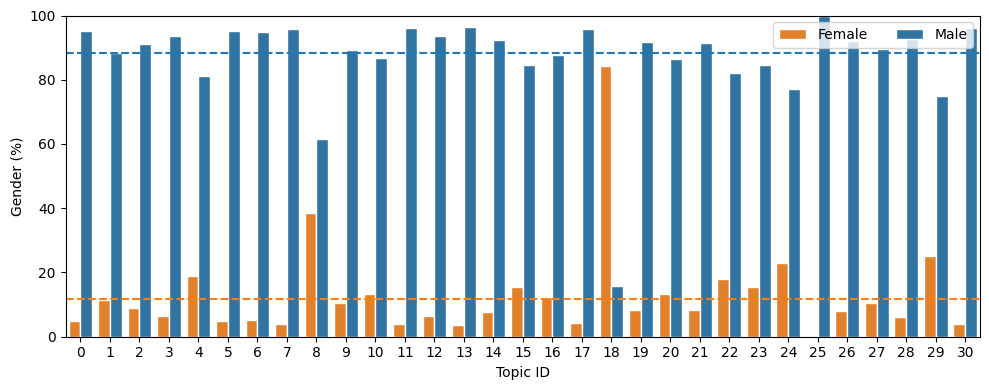

In [ ]:
gender_counts = df_videos_full_attr.groupby(['topic_id', 'gender']).size().unstack(fill_value=0)
gender_pct = gender_counts.div(gender_counts.sum(axis=1), axis=0) * 100

df_plot = gender_pct.reset_index().melt(id_vars='topic_id', value_name='percentage', var_name='gender')
df_plot['gender'] = df_plot['gender'].replace({'F': 'Female', 'M': 'Male'})

plt.figure(figsize=(10, 4))

ax = sns.barplot(
    data=df_plot,
    x='topic_id',
    y='percentage',
    hue='gender',
    palette={'Female': '#ff7f0e', 'Male': '#1f77b4'},
    edgecolor='white'
)

counts_total = df_videos_full_attr['gender'].value_counts()
pct_w_global = (counts_total['F'] / counts_total.sum()) * 100
pct_m_global = (counts_total['M'] / counts_total.sum()) * 100

plt.axhline(y=pct_w_global, color='#ff7f0e', linestyle='--')
plt.axhline(y=pct_m_global, color='#1f77b4', linestyle='--')

plt.ylabel("Gender (%)")
plt.xlabel("Topic ID")
plt.legend(loc='best', ncol=2)
plt.ylim(0, 100)

plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'videos_barras_gender_topicos.pdf'))
plt.show()

In [ ]:
print(f"A porcentagem de homens na base é de: {pct_m_global:.2f}")
print(f"A porcentagem de mulheres na base é de: {pct_w_global:.2f}")

A porcentagem de homens na base é de: 88.17
A porcentagem de mulheres na base é de: 11.83


In [ ]:
for topic_id in df_videos_full_attr['topic_id'].unique():
    target_topic = df_videos_full_attr[df_videos_full_attr['topic_id'] == topic_id]['gender'].value_counts().reindex(['M', 'F'], fill_value=0)
    other_topics = df_videos_full_attr[df_videos_full_attr['topic_id'] != topic_id]['gender'].value_counts().reindex(['M', 'F'], fill_value=0)
    
    tabela = [target_topic.values, other_topics.values]
    
    chi2, p, dof, expected = chi2_contingency(tabela)
        
    if p < (0.05 / df_videos_full_attr['topic_id'].nunique()):
        print(f"Tópico {topic_id}: A proporção de gênero é significativamente diferente do global (p={p:.4f})")

Tópico 8: A proporção de gênero é significativamente diferente do global (p=0.0000)
Tópico 0: A proporção de gênero é significativamente diferente do global (p=0.0000)
Tópico 6: A proporção de gênero é significativamente diferente do global (p=0.0012)
Tópico 7: A proporção de gênero é significativamente diferente do global (p=0.0004)
Tópico 11: A proporção de gênero é significativamente diferente do global (p=0.0006)
Tópico 13: A proporção de gênero é significativamente diferente do global (p=0.0007)
Tópico 4: A proporção de gênero é significativamente diferente do global (p=0.0001)
Tópico 5: A proporção de gênero é significativamente diferente do global (p=0.0003)
Tópico 18: A proporção de gênero é significativamente diferente do global (p=0.0000)


In [ ]:
cluster_percentage = round(df_videos_full_attr['cluster_percentage'].mean(), 2)
mean_std = round(df_videos_full_attr['age_std'].mean(), 2)

print(f'Na média, o maior cluster representa {cluster_percentage}% das faces')
print(f'Na média, o desvio padrão é de {mean_std} anos')

Na média, o maior cluster representa 97.49% das faces
Na média, o desvio padrão é de 3.77 anos


In [ ]:
print(f"A porcentagem de vídeos com consistência de gênero é: {df_videos_full_attr[df_videos_full_attr['gender_consistency'] == 1].shape[0] / df_videos_full_attr.shape[0]:.2f}")

A porcentagem de vídeos com consistência de gênero é: 0.92


In [ ]:
# Proporção de gender_consistency < 1 por tópico
consistency_by_topic = (
    df_videos_full_attr.groupby('topic_id')
    .agg(
        prop_inconsistent=('gender_consistency', lambda x: (x < 1).mean() * 100),
        n_videos=('gender_consistency', 'count')
    )
    .reset_index()
)

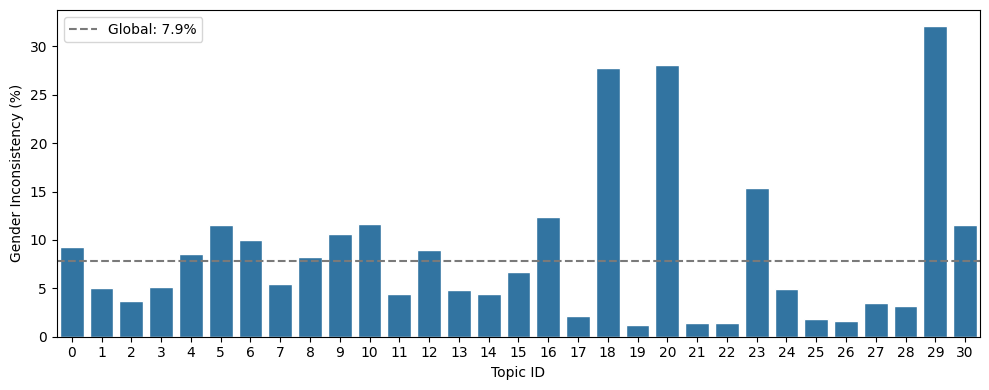

In [ ]:
prop_global = (df_videos_full_attr['gender_consistency'] < 1).mean() * 100

plt.figure(figsize=(10, 4))

sns.barplot(
    data=consistency_by_topic,
    x='topic_id',
    y='prop_inconsistent',
    color='#1f77b4',
    edgecolor='white'
)

plt.axhline(
    y=prop_global,
    linestyle='--',
    color='#7a7a7a',
    label=f'Global: {prop_global:.1f}%'
)

plt.ylabel("Gender Inconsistency (%)")
plt.xlabel("Topic ID")
plt.legend(loc='best')
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'videos_gender_consistency_topicos.pdf'))
plt.show()

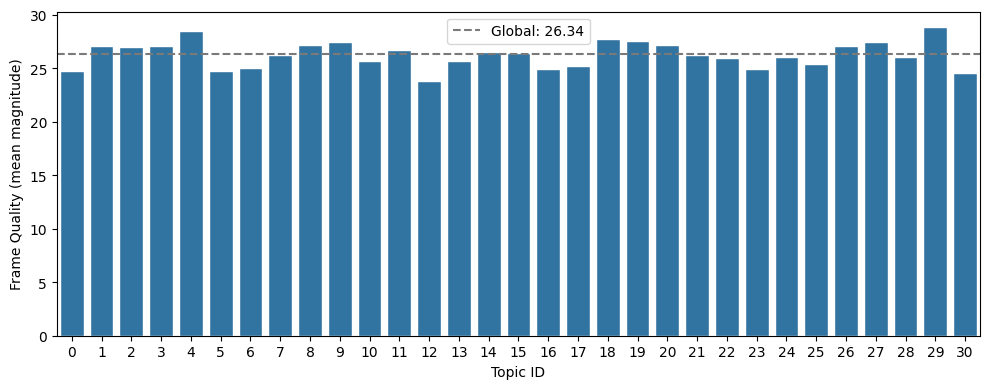

In [ ]:
quality_by_topic = (
    df_videos_full_attr.groupby('topic_id')
    .agg(mean_quality=('quality_magnitude', 'mean'))
    .reset_index()
)

quality_global = df_videos_full_attr['quality_magnitude'].mean()

plt.figure(figsize=(10, 4))

sns.barplot(
    data=quality_by_topic,
    x='topic_id',
    y='mean_quality',
    color='#1f77b4',
    edgecolor='white'
)

plt.axhline(
    y=quality_global,
    linestyle='--',
    color='#7a7a7a',
    label=f'Global: {quality_global:.2f}'
)

plt.ylabel("Frame Quality (mean magnitude)")
plt.xlabel("Topic ID")
plt.legend(loc='best')
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'videos_frame_quality_topicos.pdf'))
plt.show()

In [ ]:
df_videos_full_attr['is_inconsistent'] = df_videos_full_attr['gender_consistency'] < 1

for topic_id in df_videos_full_attr['topic_id'].unique():
    target_topic = df_videos_full_attr[df_videos_full_attr['topic_id'] == topic_id]['is_inconsistent'].value_counts().reindex([False, True], fill_value=0)
    other_topics = df_videos_full_attr[df_videos_full_attr['topic_id'] != topic_id]['is_inconsistent'].value_counts().reindex([False, True], fill_value=0)
    
    tabela = [target_topic.values, other_topics.values]
    
    chi2, p, dof, expected = chi2_contingency(tabela)
    
    alpha_corrigido = 0.05 / df_videos_full_attr['topic_id'].nunique()
    
    if p < alpha_corrigido:
        print(f"Tópico {topic_id}: A proporção de inconsistências é significativamente diferente do global (p={p:.4f})")

Tópico 20: A proporção de inconsistências é significativamente diferente do global (p=0.0000)
Tópico 18: A proporção de inconsistências é significativamente diferente do global (p=0.0000)
Tópico 29: A proporção de inconsistências é significativamente diferente do global (p=0.0000)


In [ ]:
canais_incons = df_videos_full_attr[df_videos_full_attr['is_inconsistent']].groupby('topic_id')['channel_id'].nunique()
total_canais = df_videos_full_attr.groupby('topic_id')['channel_id'].nunique()

df_canais_incons = pd.DataFrame({
    'topic_id': total_canais.index,
    'canais_inconsistentes': canais_incons.reindex(total_canais.index, fill_value=0).values,
    'total_canais': total_canais.values,
    'proporcao': (canais_incons.reindex(total_canais.index, fill_value=0) / total_canais * 100).round(2).values
})

canais_incons_global = df_videos_full_attr[df_videos_full_attr['is_inconsistent']]['channel_id'].nunique()
total_canais_global = df_videos_full_attr['channel_id'].nunique()
prop_canais_incons_global = round(canais_incons_global / total_canais_global * 100, 2)

print(f"Proporção global: {prop_canais_incons_global}% dos canais ({canais_incons_global}/{total_canais_global})")

df_canais_incons

Proporção global: 14.39% dos canais (174/1209)


,topic_id,canais_inconsistentes,total_canais,proporcao
0,0,26,152,17.11
1,1,22,190,11.58
2,2,13,200,6.50
3,3,14,144,9.72
4,4,25,163,15.34
5,5,9,61,14.75
6,6,18,116,15.52
7,7,6,89,6.74
8,8,18,159,11.32
9,9,21,112,18.75
